## HW 2

1. Скачайте 1079 геномов из 30 российских популяций с сайта http://
www.russiangenome.ru/
2. Сделайте LD-pruning с помощью PLINK (скачивается бинарный файл)
3. С помощью PLINK найдите координаты перых пяти главных компонент.
4. Визуализируйте их попарно.
5. Проанализируйте график PC1 vs PC2. Наблюдается ли кластеризация популяции?
Соответствует ли расположение популяций ожиданиям исходя из их географического
распространения?

In [ ]:
import matplotlib.pyplot as plt

from pathlib import Path
import subprocess

import pandas as pd

Первое что я сделал - скачал архив данных и архив бинаря PLINK 2.0 (alpha версия на мой mac apple silicon)

Далее напишу утилиту для запуска команд, обращенных к бинарю, поскольку lib plynk для питона на маке не завелась. Будем исполнять ручками.

In [15]:
PLINK2 = Path("plink2_mac_arm64_20260228/plink2")
DATA_PREFIX = Path("biengi/biengi")
OUT_DIR = Path("biengi/results")
OUT_DIR.mkdir(exist_ok=True)

def run_plink2(args):
    cmd = [str(PLINK2), *map(str, args)]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("plink2 failed command on binary")
    if result.stdout:
        print(result.stdout)

    return result

In [ ]:
# Тест команды plink2
run_plink2(["--help"])

PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/
(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3

In the command line flag definitions that follow,
  * <angle brackets> denote a required parameter, where the text between the
    angle brackets describes its nature.
  * ['square brackets + single-quotes'] denotes an optional modifier.  Use the
    EXACT text in the quotes.
  * [{bar|separated|braced|bracketed|values}] denotes a collection of mutually
    exclusive optional modifiers (again, the exact text must be used).  When
    there are no outer square brackets, one of the choices must be selected.
  * ['quoted_text='<description of value>] denotes an optional modifier that
    must begin with the quoted text, and be followed by a value with no
    whitespace in between.  '|' may also be used here to indicate mutually
    exclusive options.
  * [square brackets without quotes or braces] denote an optional parameter,
    w

CompletedProcess(args=['plink2_mac_arm64_20260228/plink2', '--help'], returncode=0, stdout='PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/\n(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3\n\nIn the command line flag definitions that follow,\n  * <angle brackets> denote a required parameter, where the text between the\n    angle brackets describes its nature.\n  * [\'square brackets + single-quotes\'] denotes an optional modifier.  Use the\n    EXACT text in the quotes.\n  * [{bar|separated|braced|bracketed|values}] denotes a collection of mutually\n    exclusive optional modifiers (again, the exact text must be used).  When\n    there are no outer square brackets, one of the choices must be selected.\n  * [\'quoted_text=\'<description of value>] denotes an optional modifier that\n    must begin with the quoted text, and be followed by a value with no\n    whitespace in between.  \'|\' may also be used here to indicate mut

Сначала пофильтруем мусор, запустив quality control (QC)

- Удаляем SNP с большим числом гэпов в данных (--geno = 0.1 - удаление при доле утери генотипа > 10%)
- Теперь то же для индивидов (--mind = 0.1 - удаление при доле утери генотипа > 10%)
- Убираем редкие варианты аллелей во избежании шума (--maf 0.05 - частота минорного аллеля > 5%)

In [18]:
qc_prefix = OUT_DIR / "qc"
run_plink2([
    "--bfile", DATA_PREFIX,
    "--geno", 0.1,
    "--mind", 0.1,
    "--maf", 0.05,
    "--make-bed",
    "--out", qc_prefix,
])


PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/
(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3
Logging to biengi/results/qc.log.
Options in effect:
  --bfile biengi/biengi
  --geno 0.1
  --maf 0.05
  --make-bed
  --mind 0.1
  --out biengi/results/qc

Start time: Thu Apr 16 17:29:20 2026
32768 MiB RAM detected; reserving 16384 MiB for main workspace.
Using up to 12 threads (change this with --threads).
894 samples (320 females, 574 males; 894 founders) loaded from
biengi/biengi.fam.
242180 variants loaded from biengi/biengi.bim.
Note: No phenotype data present.
Calculating sample missingness rates... 275481done.
0 samples removed due to missing genotype data (--mind).
894 samples (320 females, 574 males; 894 founders) remaining after main
filters.
Calculating allele frequencies... 275481done.
--geno: 0 variants removed due to missing genotype data.
7474 variants removed due to allele frequency threshold(s)
(--maf/--max-maf

CompletedProcess(args=['plink2_mac_arm64_20260228/plink2', '--bfile', 'biengi/biengi', '--geno', '0.1', '--mind', '0.1', '--maf', '0.05', '--make-bed', '--out', 'biengi/results/qc'], returncode=0, stdout='PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/\n(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3\nLogging to biengi/results/qc.log.\nOptions in effect:\n  --bfile biengi/biengi\n  --geno 0.1\n  --maf 0.05\n  --make-bed\n  --mind 0.1\n  --out biengi/results/qc\n\nStart time: Thu Apr 16 17:29:20 2026\n32768 MiB RAM detected; reserving 16384 MiB for main workspace.\nUsing up to 12 threads (change this with --threads).\n894 samples (320 females, 574 males; 894 founders) loaded from\nbiengi/biengi.fam.\n242180 variants loaded from biengi/biengi.bim.\nNote: No phenotype data present.\nCalculating sample missingness rates... 0%\x08\x0827%\x08\x08\x0854%\x08\x08\x0881%\x08\x08\x08done.\n0 samples removed due to missing genotype d

Теперь надо сделать LD (linkage disequilibrium) pruning. Устраняем корелляции соседних SNP, двигаясь с оффсетом и окном.

In [19]:
prune_prefix = OUT_DIR / "pruned"
run_plink2([
    "--bfile", qc_prefix,
    "--indep-pairwise", 50, 5, 0.2,
    "--out", prune_prefix,
])

PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/
(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3
Logging to biengi/results/pruned.log.
Options in effect:
  --bfile biengi/results/qc
  --indep-pairwise 50 5 0.2
  --out biengi/results/pruned

Start time: Thu Apr 16 17:31:25 2026
32768 MiB RAM detected; reserving 16384 MiB for main workspace.
Using up to 12 threads (change this with --threads).
894 samples (320 females, 574 males; 894 founders) loaded from
biengi/results/qc.fam.
234706 variants loaded from biengi/results/qc.bim.
Note: No phenotype data present.
Calculating allele frequencies... 275583done.
--indep-pairwise (11 compute threads): 50160040/234706 variants removed.
Writing...
Variant lists written to biengi/results/pruned.prune.in and
biengi/results/pruned.prune.out .
End time: Thu Apr 16 17:31:25 2026



CompletedProcess(args=['plink2_mac_arm64_20260228/plink2', '--bfile', 'biengi/results/qc', '--indep-pairwise', '50', '5', '0.2', '--out', 'biengi/results/pruned'], returncode=0, stdout='PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/\n(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3\nLogging to biengi/results/pruned.log.\nOptions in effect:\n  --bfile biengi/results/qc\n  --indep-pairwise 50 5 0.2\n  --out biengi/results/pruned\n\nStart time: Thu Apr 16 17:31:25 2026\n32768 MiB RAM detected; reserving 16384 MiB for main workspace.\nUsing up to 12 threads (change this with --threads).\n894 samples (320 females, 574 males; 894 founders) loaded from\nbiengi/results/qc.fam.\n234706 variants loaded from biengi/results/qc.bim.\nNote: No phenotype data present.\nCalculating allele frequencies... 0%\x08\x0827%\x08\x08\x0855%\x08\x08\x0883%\x08\x08\x08done.\n--indep-pairwise (11 compute threads): 0%\x08\x0850%\x08\x08\x08160040/2347

Сохраняем bed по финальному qc с LD-Pruning

In [22]:
qc_pruned_prefix = OUT_DIR / "qc_pruned"
run_plink2([
    "--bfile", qc_prefix,
    "--extract", f"{prune_prefix}.prune.in",
    "--make-bed",
    "--out", qc_pruned_prefix,
])

PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/
(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3
Logging to biengi/results/qc_pruned.log.
Options in effect:
  --bfile biengi/results/qc
  --extract biengi/results/pruned.prune.in
  --make-bed
  --out biengi/results/qc_pruned

Start time: Thu Apr 16 17:32:07 2026
32768 MiB RAM detected; reserving 16384 MiB for main workspace.
Using up to 12 threads (change this with --threads).
894 samples (320 females, 574 males; 894 founders) loaded from
biengi/results/qc.fam.
234706 variants loaded from biengi/results/qc.bim.
Note: No phenotype data present.
--extract: 74666 variants remaining.
74666 variants remaining after main filters.
Writing biengi/results/qc_pruned.fam ... done.
Writing biengi/results/qc_pruned.bim ... done.
Writing biengi/results/qc_pruned.bed ... 275382done.
End time: Thu Apr 16 17:32:07 2026



CompletedProcess(args=['plink2_mac_arm64_20260228/plink2', '--bfile', 'biengi/results/qc', '--extract', 'biengi/results/pruned.prune.in', '--make-bed', '--out', 'biengi/results/qc_pruned'], returncode=0, stdout='PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/\n(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3\nLogging to biengi/results/qc_pruned.log.\nOptions in effect:\n  --bfile biengi/results/qc\n  --extract biengi/results/pruned.prune.in\n  --make-bed\n  --out biengi/results/qc_pruned\n\nStart time: Thu Apr 16 17:32:07 2026\n32768 MiB RAM detected; reserving 16384 MiB for main workspace.\nUsing up to 12 threads (change this with --threads).\n894 samples (320 females, 574 males; 894 founders) loaded from\nbiengi/results/qc.fam.\n234706 variants loaded from biengi/results/qc.bim.\nNote: No phenotype data present.\n--extract: 74666 variants remaining.\n74666 variants remaining after main filters.\nWriting biengi/results/qc_

In [23]:
pca_prefix = OUT_DIR / "pca"
run_plink2([
    "--bfile", qc_pruned_prefix,
    "--pca", 5,
    "--out", pca_prefix,
])


PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/
(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3
Logging to biengi/results/pca.log.
Options in effect:
  --bfile biengi/results/qc_pruned
  --out biengi/results/pca
  --pca 5

Start time: Thu Apr 16 17:32:14 2026
32768 MiB RAM detected; reserving 16384 MiB for main workspace.
Using up to 12 threads (change this with --threads).
894 samples (320 females, 574 males; 894 founders) loaded from
biengi/results/qc_pruned.fam.
74666 variants loaded from biengi/results/qc_pruned.bim.
Note: No phenotype data present.
Calculating allele frequencies... 87done.
Constructing GRM: 101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555657585960616263646566676869707172737475767778798081828384858687888990919293949596979899done.
Correcting for missingness... 1011121314151617181920212223242526272829303132333435363738394041424344454647484950515253545556575859

CompletedProcess(args=['plink2_mac_arm64_20260228/plink2', '--bfile', 'biengi/results/qc_pruned', '--pca', '5', '--out', 'biengi/results/pca'], returncode=0, stdout='PLINK v2.0.0-a.6.33 M1 (28 Feb 2026)                cog-genomics.org/plink/2.0/\n(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3\nLogging to biengi/results/pca.log.\nOptions in effect:\n  --bfile biengi/results/qc_pruned\n  --out biengi/results/pca\n  --pca 5\n\nStart time: Thu Apr 16 17:32:14 2026\n32768 MiB RAM detected; reserving 16384 MiB for main workspace.\nUsing up to 12 threads (change this with --threads).\n894 samples (320 females, 574 males; 894 founders) loaded from\nbiengi/results/qc_pruned.fam.\n74666 variants loaded from biengi/results/qc_pruned.bim.\nNote: No phenotype data present.\nCalculating allele frequencies... 0%\x08\x0887%\x08\x08\x08done.\nConstructing GRM: 0%\x08\x081%\x08\x082%\x08\x083%\x08\x084%\x08\x085%\x08\x086%\x08\x087%\x08\x088%\x08\x089%\x08\x0810%\x08\x08

Далее занимаемся обработкой выходных файлов с PCA (5 главных компонент с пред шага) и обработкой метаданных из входных файлов.

In [ ]:
# PCA на выходе (уже qc+ld-pruned)
pca = pd.read_csv("biengi/results/pca.eigenvec", sep=r"\s+", header=None)
pca.columns = ["FID", "IID", "PC1", "PC2", "PC3", "PC4", "PC5"]

# метаданные, где есть разметка по популяции, полу, родству
meta = pd.read_csv("biengi/biengi.pedind", sep="\t", header=None)
meta.columns = ["FID", "IID", "father", "mother", "sex", "population"]

# Merge
pca_meta = pca.merge(
    meta[["FID", "IID", "population"]],
    on=["FID", "IID"],
    how="left"
)

# политика заполнения NaN невалидных значений
pca_meta["PC1"] = pd.to_numeric(pca_meta["PC1"], errors="coerce")
pca_meta["PC2"] = pd.to_numeric(pca_meta["PC2"], errors="coerce")
pca_meta["PC3"] = pd.to_numeric(pca_meta["PC3"], errors="coerce")
pca_meta["PC4"] = pd.to_numeric(pca_meta["PC4"], errors="coerce")
pca_meta["PC5"] = pd.to_numeric(pca_meta["PC5"], errors="coerce")

pca_meta.dropna(inplace=True)

Ниже вспомагательная функция сравнения двух произвольных PC. P.S. главное передавать PC1-5 (верный диапазон)

In [41]:
def plot_pca(pca_meta, left_component_num = "PC1", right_component_num = "PC2"):
    # Выделяем центры популяций
    centers = (
        pca_meta
        .groupby("population")[[left_component_num, right_component_num]]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(15, 11))

    # Рисуем графички
    for _, df_pop in pca_meta.groupby("population"):
        plt.scatter(df_pop[left_component_num], df_pop[right_component_num], s=20, alpha=0.65)

    for _, row in centers.iterrows():
        plt.text(
            row[left_component_num],
            row[right_component_num],
            str(row["population"]),
            fontsize=12,
            ha="center",
            va="center",
            bbox=dict(boxstyle="round", fc="white", alpha=0.3, ec="none")
        )

    plt.xlabel(left_component_num)
    plt.ylabel(right_component_num)
    plt.title("PCA популяций")
    plt.tight_layout()
    plt.show()

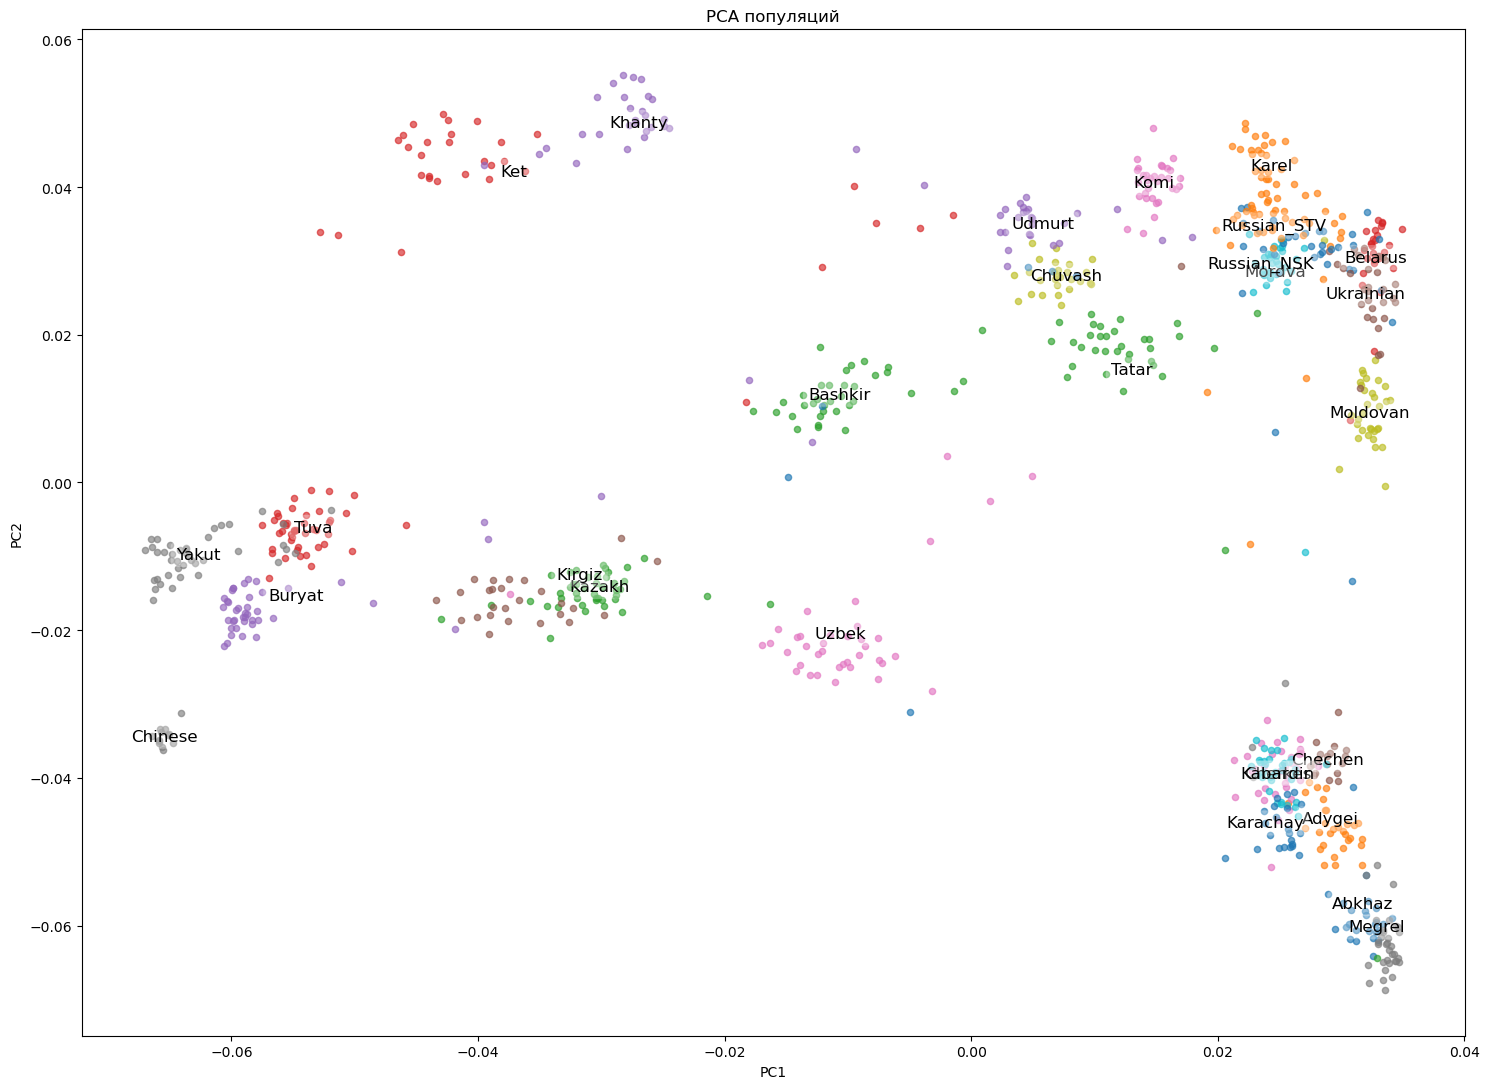

In [45]:
plot_pca(pca_meta, "PC1", "PC2")


Наблюдения по PC1 и PC2:

1) Якуты, буряты и тувинцы отдельно сформировали отдельный кластер от других популяций, также как и кеты/ханты.

2) Видно четко, что южная часть России в том диапазоне тоже выделилась (чеченцы, абхазцы, кабардины, карачаевцы)

3) Русские популяции образуют отдельную компактную область в правой верхней части графика.

4) Удмуртцы, татары и чуваши отдельно лежат и видно, что отличаются от обычных русских популяций, хоть и живут давно вместе

5) В центральной части графика располагаются некоторые промежуточные группы, например узбеки, киргизы и близкие к ним популяции, что может отражать смешанное или промежуточное положение относительно других кластеров.

6) При этом часть популяций частично перекрывается, поэтому PCA показывает не строго изолированные группы, а общую структуру генетической близости.

7) В целом расположение популяций на графике соответствует географическим ожиданиям: более удалённые по происхождению и региону группы лежат дальше друг от друга, а географически близкие популяции чаще оказываются рядом.


In [50]:
eigenval = pd.read_csv("biengi/results/pca.eigenval", header=None, names=["eigenvalue"])

eigenval["explained_variance_ratio"] = eigenval["eigenvalue"] / eigenval["eigenvalue"].sum()
eigenval["explained_variance_percent"] = 100 * eigenval["explained_variance_ratio"]
eigenval["cumulative_percent"] = eigenval["explained_variance_percent"].cumsum()


eigenval.index = [f"PC{i}" for i in range(1, len(eigenval) + 1)]
print(eigenval.head(5))

     eigenvalue  explained_variance_ratio  explained_variance_percent  \
PC1    32.86570                  0.675662                   67.566159   
PC2     6.79585                  0.139711                   13.971085   
PC3     3.96785                  0.081572                    8.157209   
PC4     2.59783                  0.053407                    5.340686   
PC5     2.41502                  0.049649                    4.964861   

     cumulative_percent  
PC1           67.566159  
PC2           81.537244  
PC3           89.694453  
PC4           95.035139  
PC5          100.000000  


Вывел отдельно вклады главных копмпонент, видно, что почти 70% вносит PC1, вместе с PC2 уже 81%, что составляет большую часть. Далее вклад идет на убывание с каждой след компонентой.

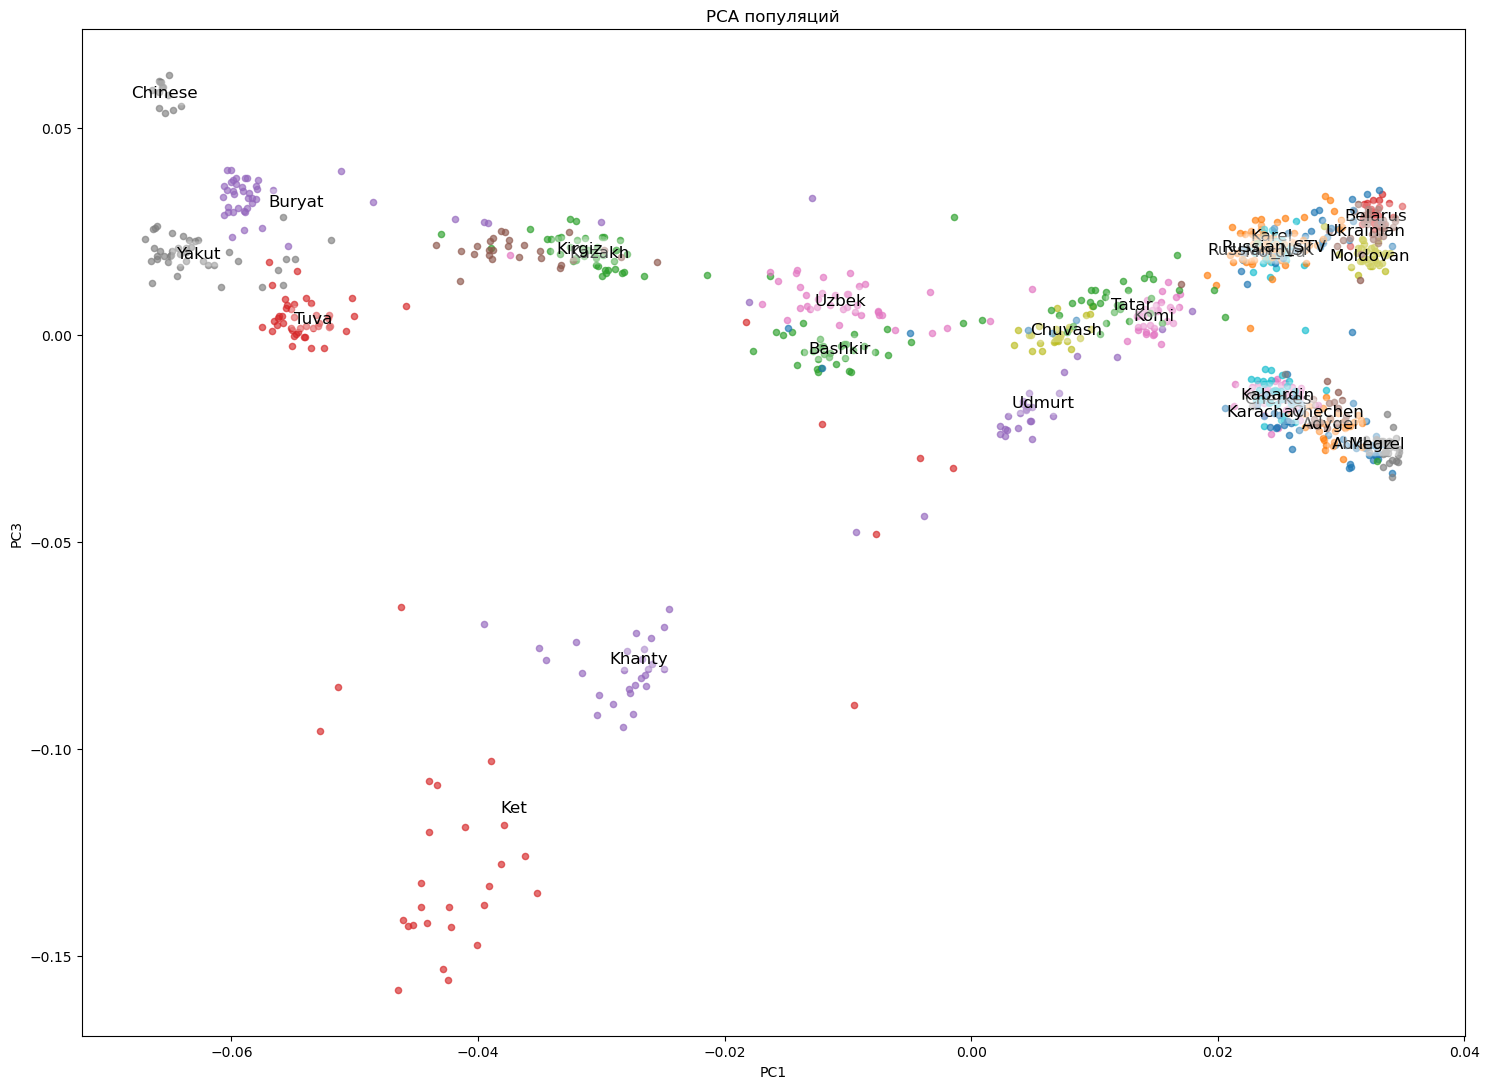

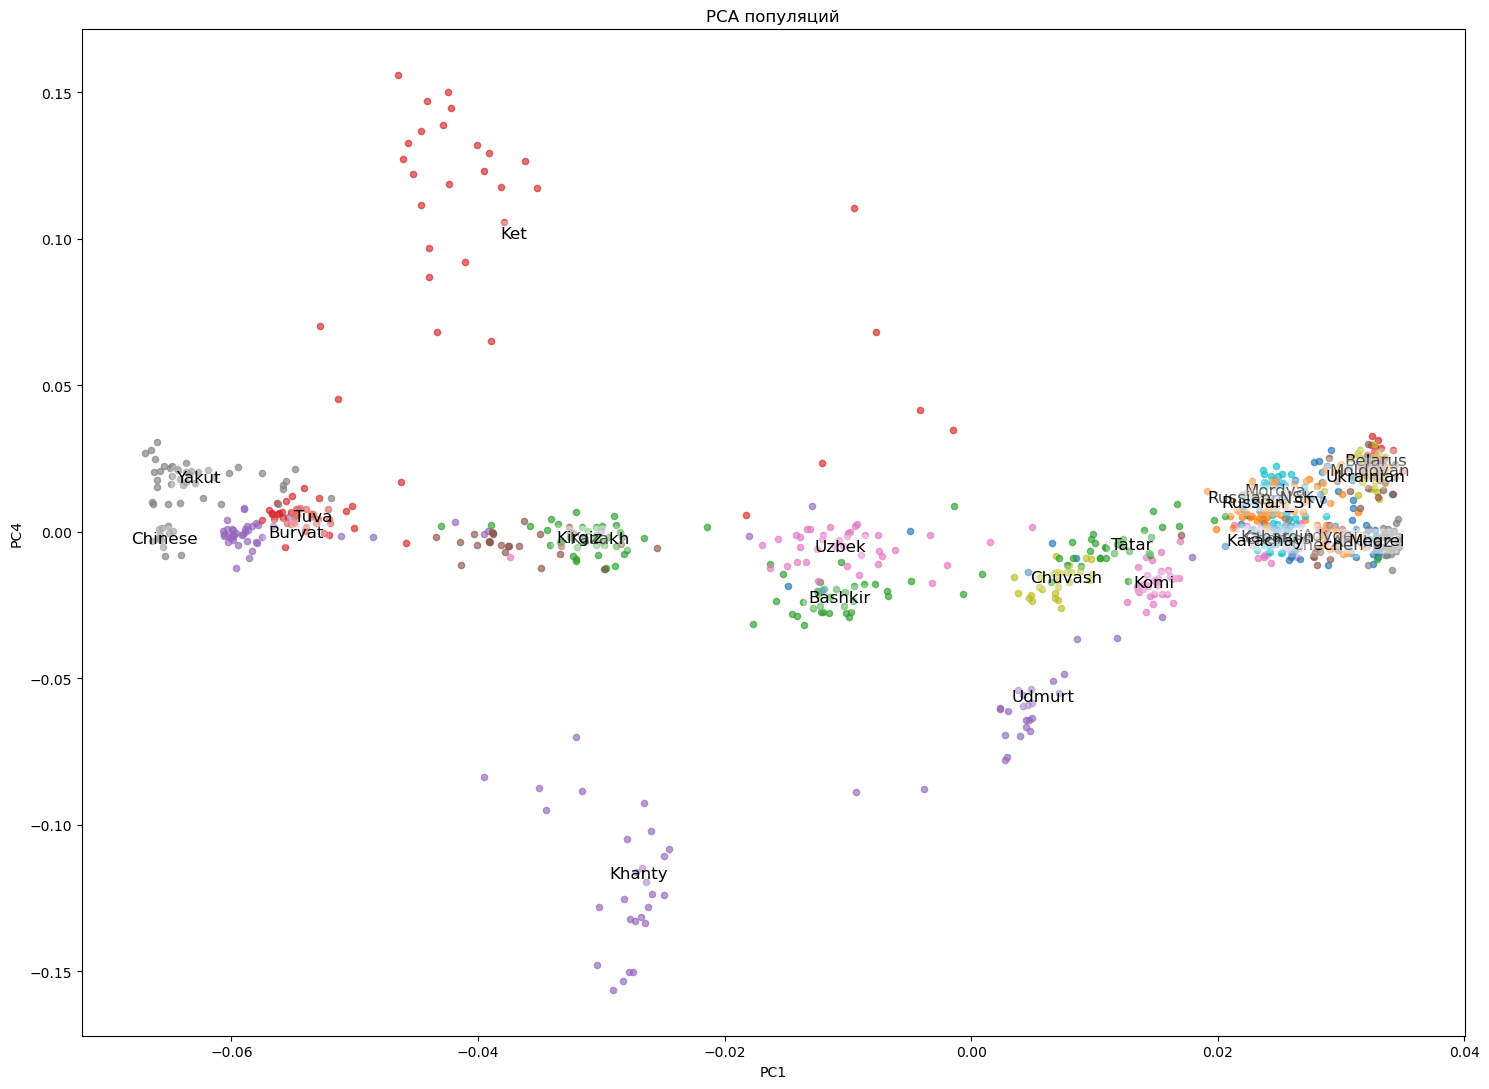

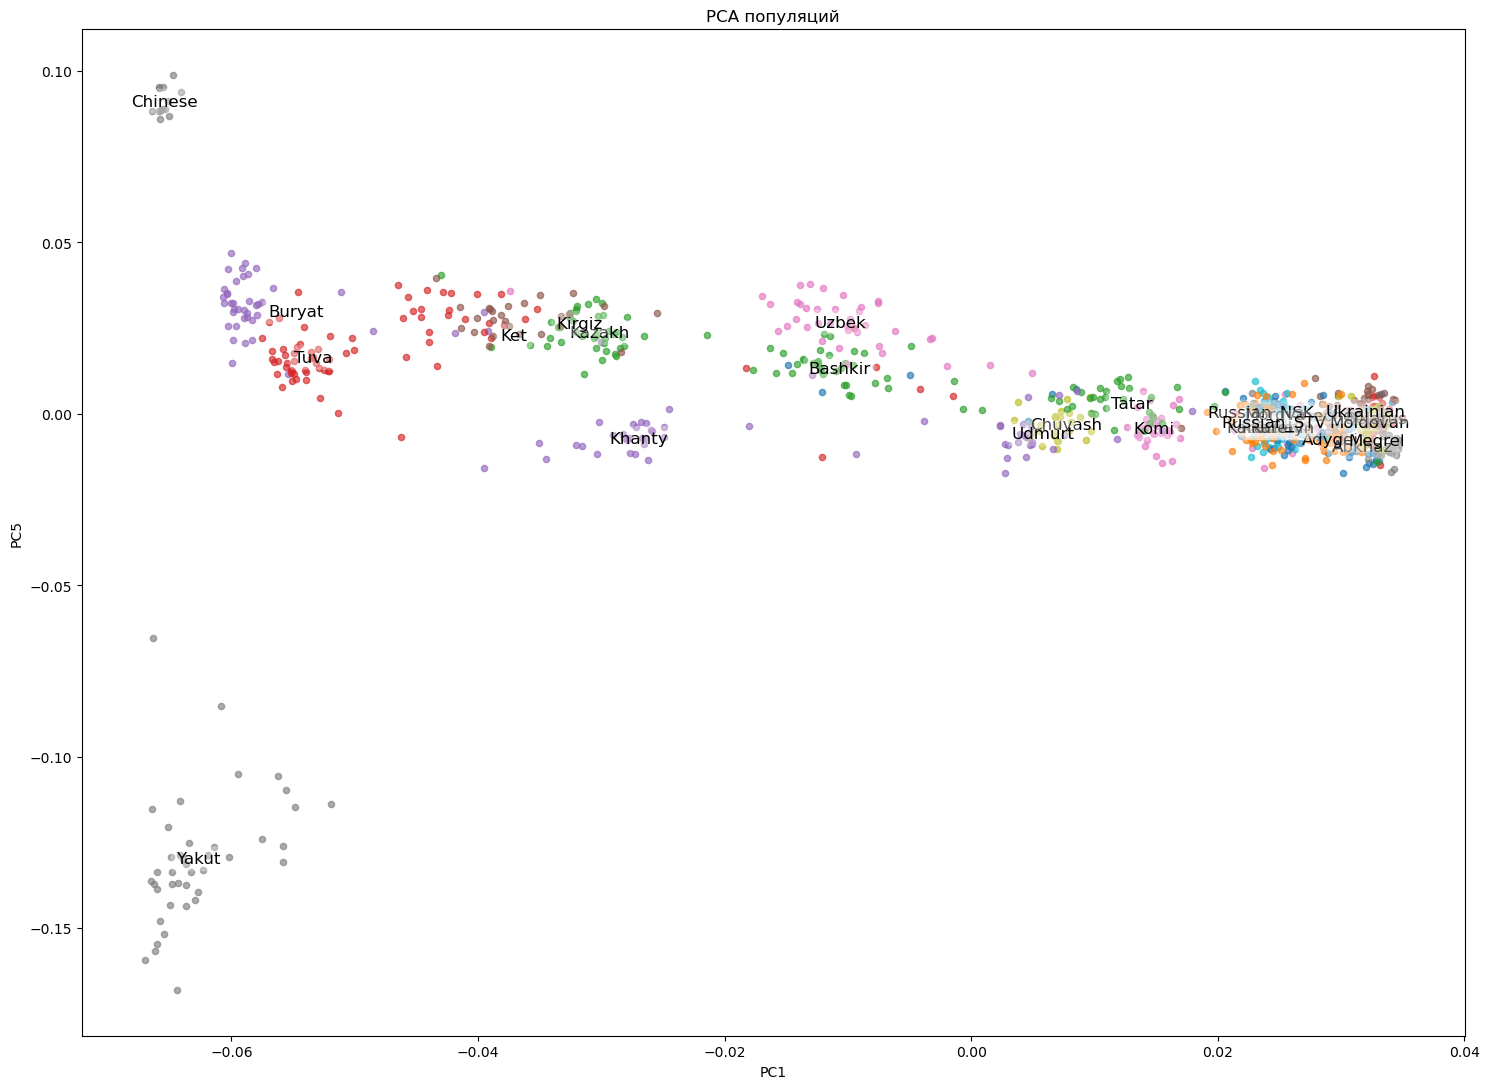

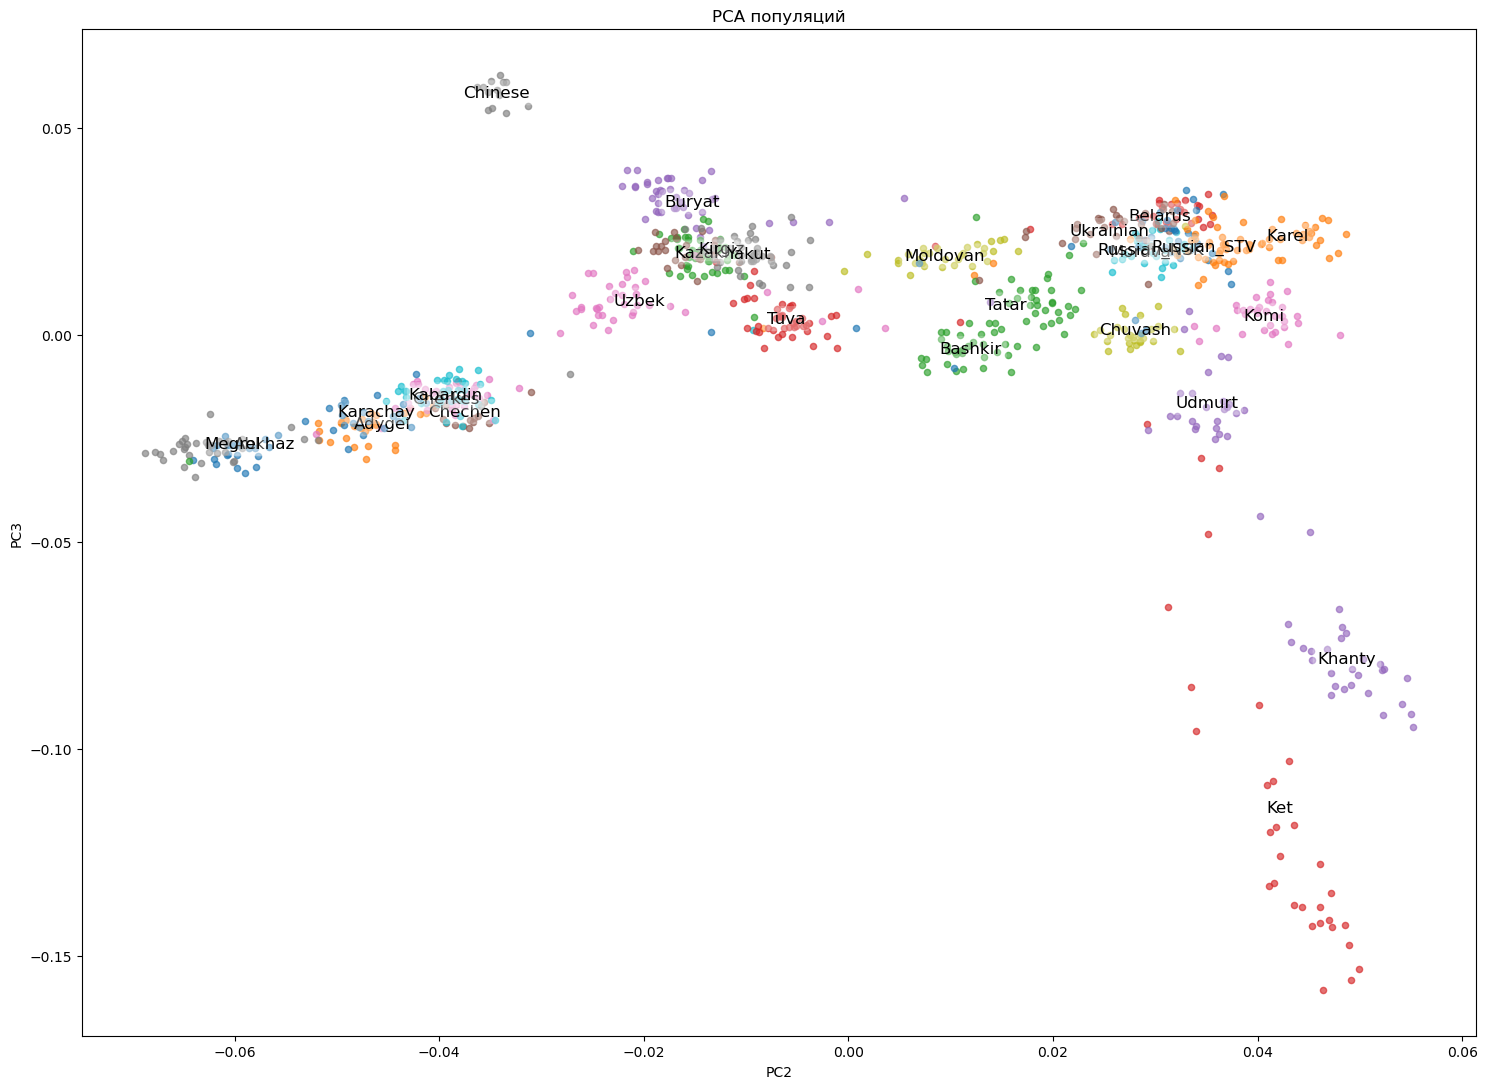

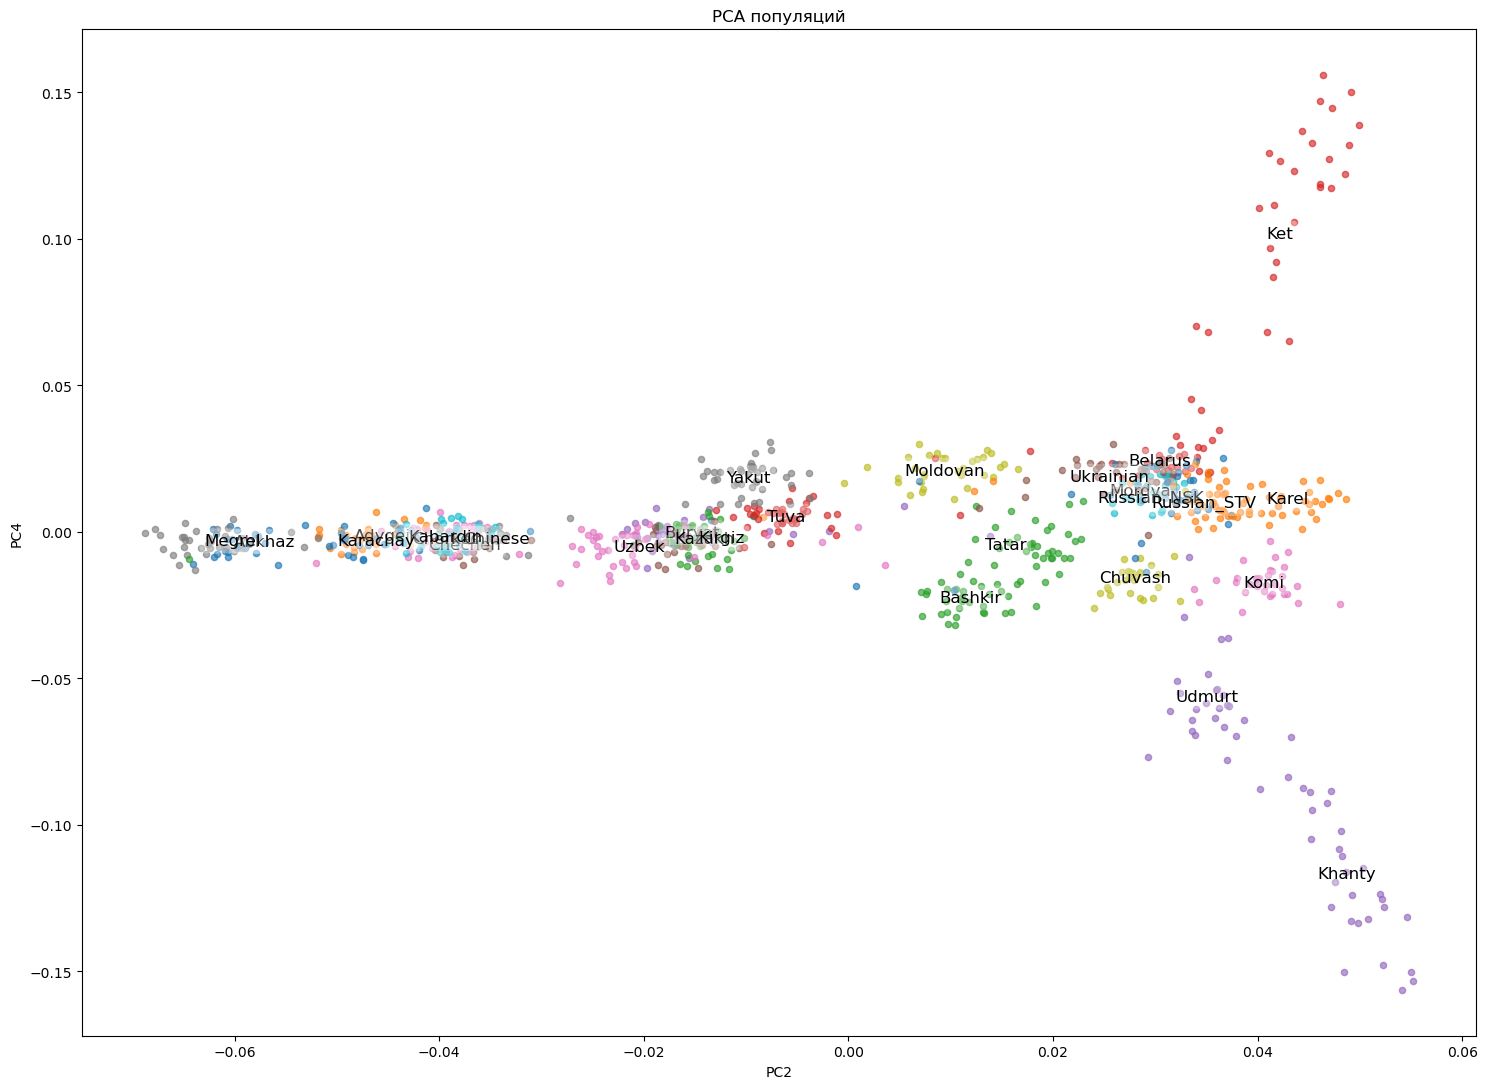

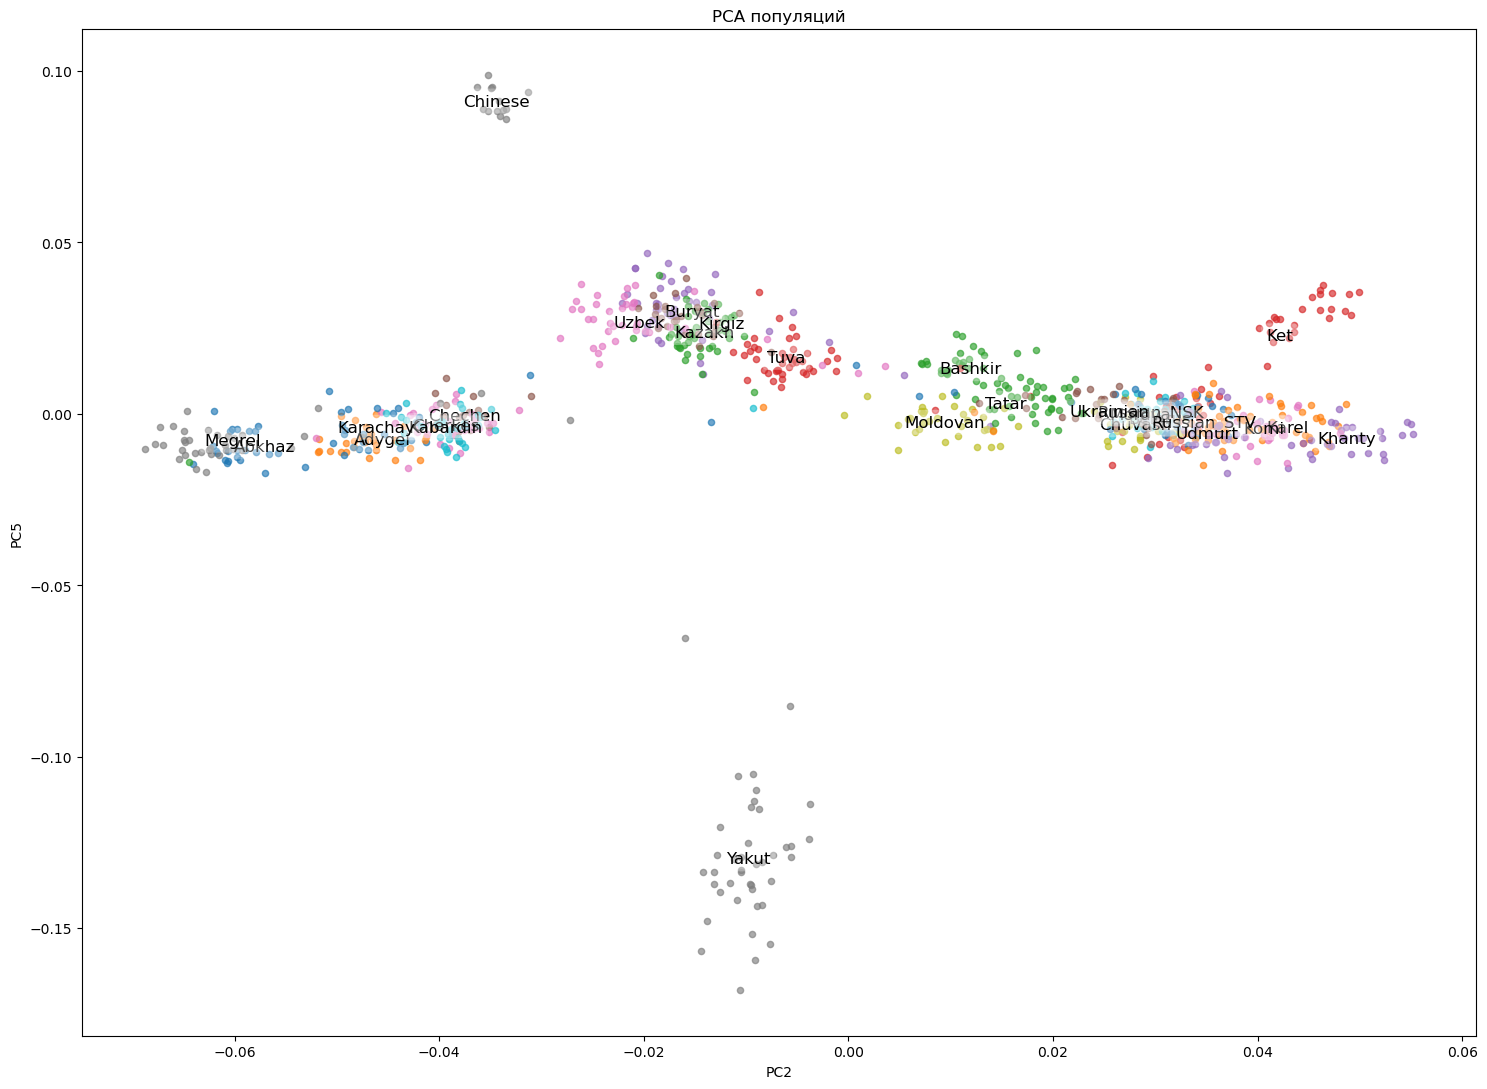

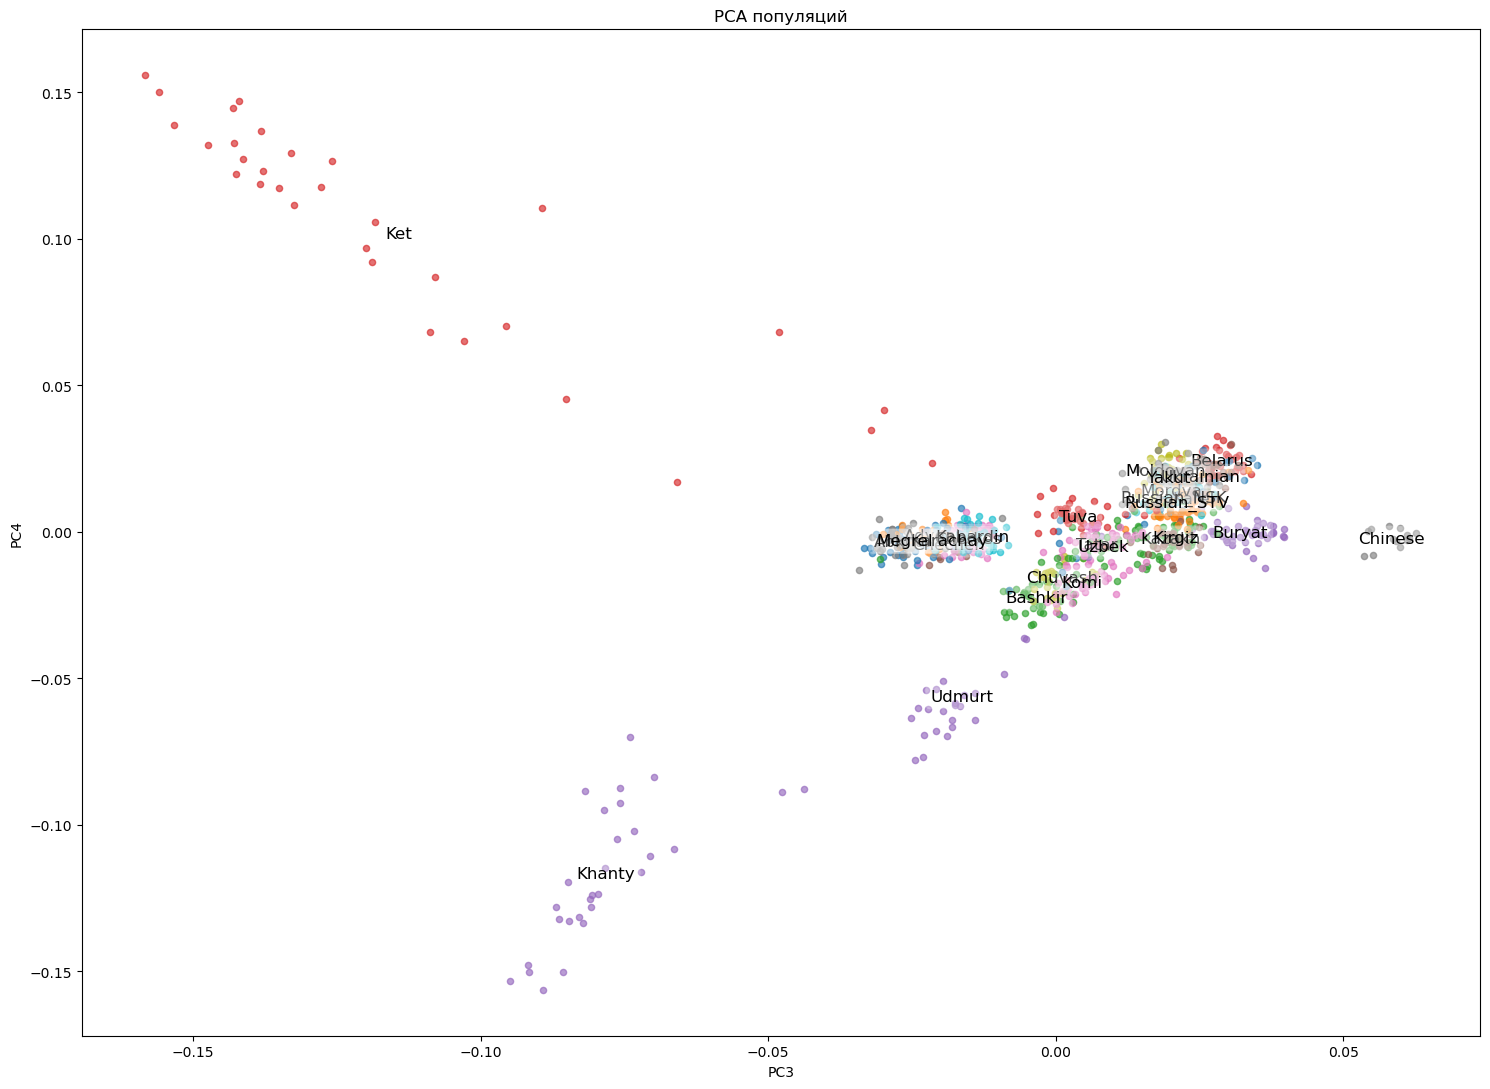

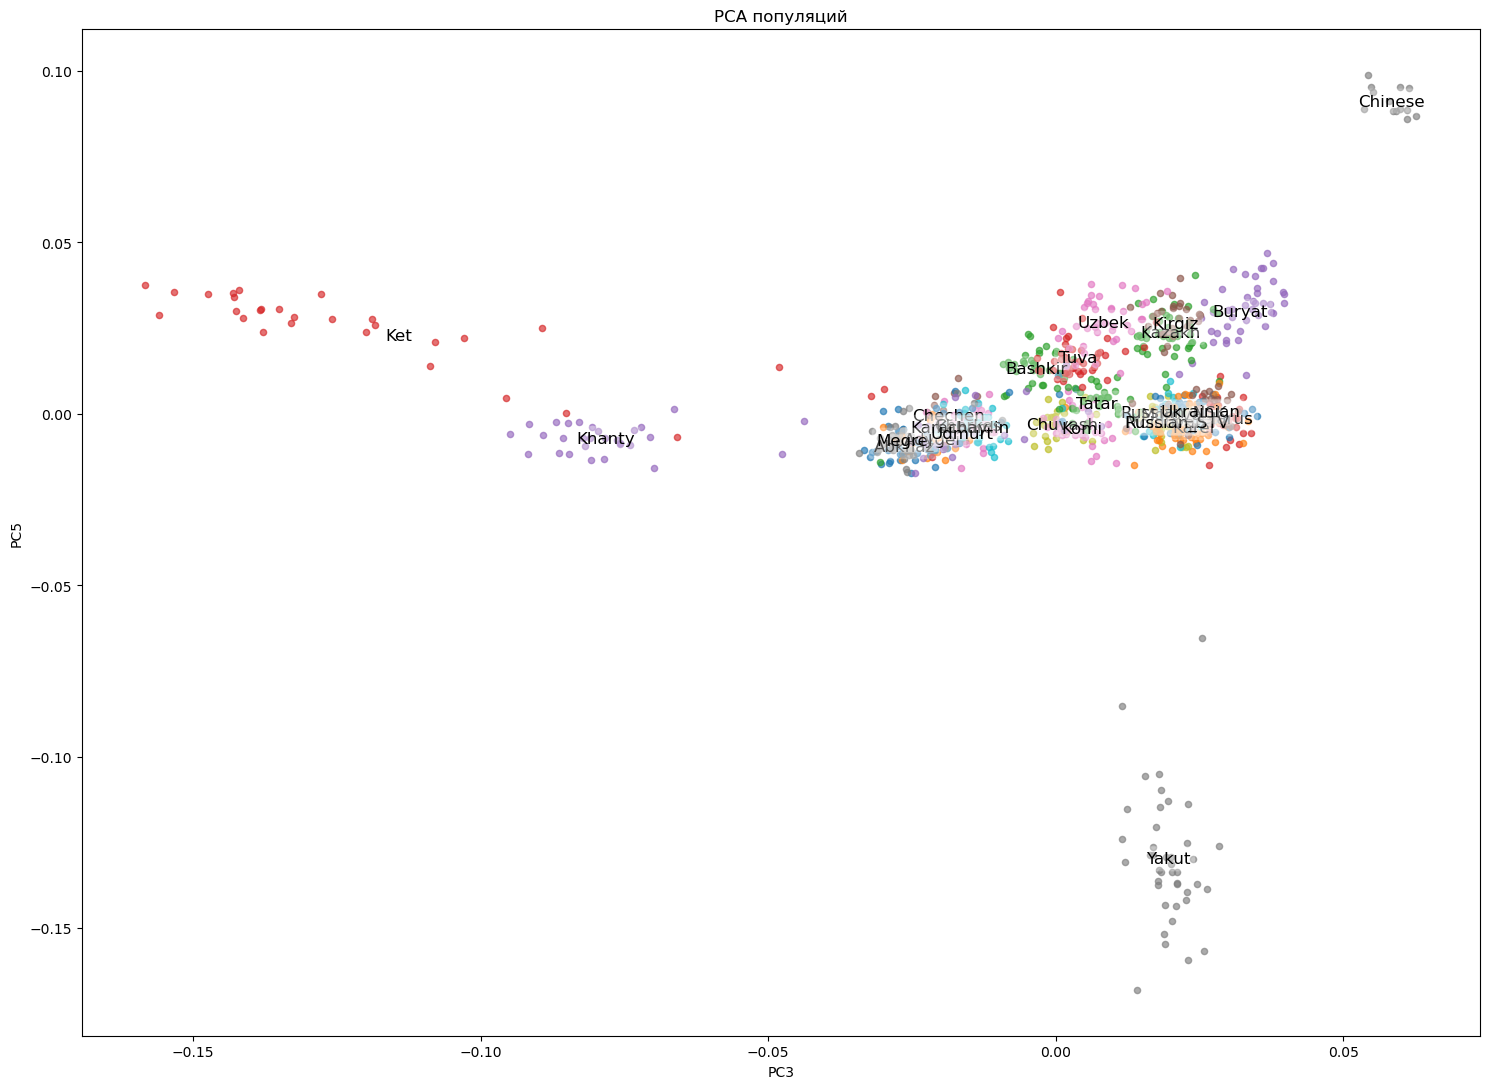

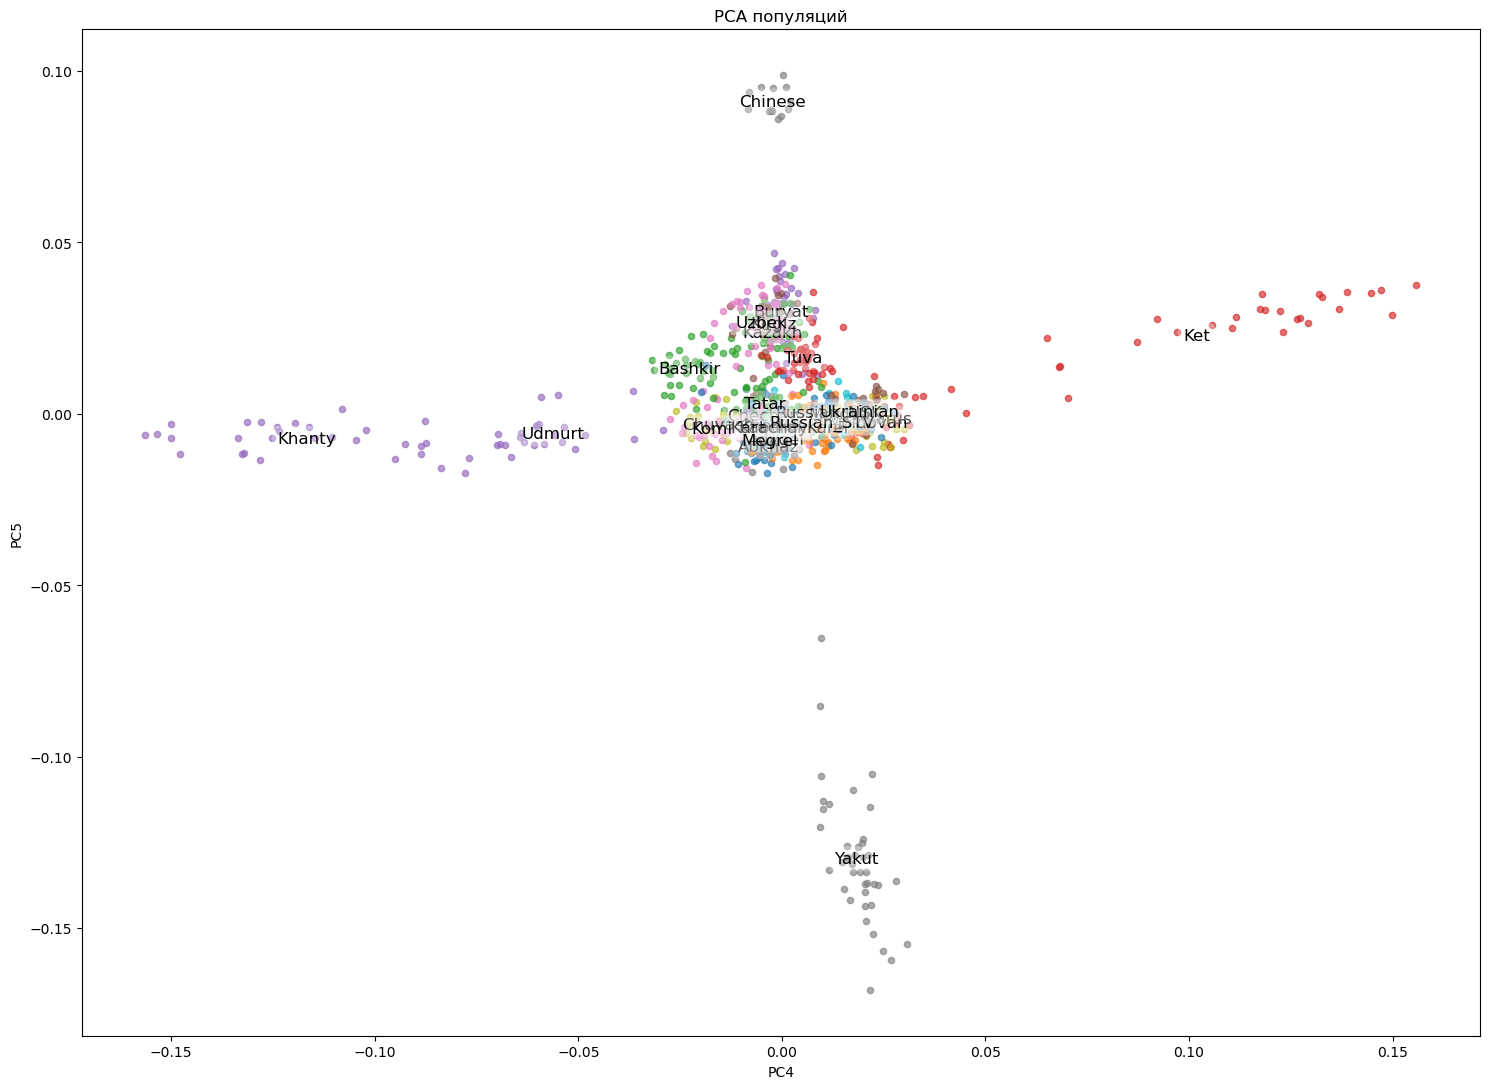

In [ ]:
# Остальные 9 комбинаций
plot_pca(pca_meta, "PC1", "PC3")
plot_pca(pca_meta, "PC1", "PC4")
plot_pca(pca_meta, "PC1", "PC5")
plot_pca(pca_meta, "PC2", "PC3")
plot_pca(pca_meta, "PC2", "PC4")
plot_pca(pca_meta, "PC2", "PC5")
plot_pca(pca_meta, "PC3", "PC4")
plot_pca(pca_meta, "PC3", "PC5")
plot_pca(pca_meta, "PC4", "PC5")

Мои наблюдения на попарные сочетания PC1-PC5 (10 комбинаций в сумме). 

1) PCA в целом должен брать максимально разбросанные проекции по дисперсии и конструировать визуально более разбросанные данные при первых компонентах

2) Чем дальше компоненты, тем менее разбросанные данные, на последних компонентах можно заметить, что популяции сильно кучкуются (особенно традиционные русские нации)

3) При этом отдельные наименее похожие по геному на другие популяции на более далеких компонентах сильно расплываются и четко видно, что какие-нибудь Якуты сильно отличаются от российской нации, китайцев, хотя при этом они были на первых компонентах прям рядышком

4) Все проекции имеют своё место быть, можно сравнивать на более важный общую картину, а частные случаи, что изначально выглядят максимально похожими (китайцы/якуты)